## 画图

In [ ]:
# c4-绘制句子长度和token长度的密度图
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator, FuncFormatter

# 设置全局样式参数
sns.set(style="whitegrid", font="SimHei")  # 设置网格背景和中文字体

x_max = 60

# 加载数据
sent_length_list = np.load('draw-data/f-c4-title句子长度数组.npy')
sent_token_length_list = np.load('draw-data/f-c4-title句子token长度数组.npy')

# 创建图形对象
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

# 绘制句子长度的密度图
sns.kdeplot(sent_length_list, color='#0984e3', lw=2, ax=ax, label="Sentence Length", bw_adjust=100)  # 蓝色

# 绘制token长度的密度图
sns.kdeplot(sent_token_length_list, color='#6c5ce7', lw=2, ax=ax, label="Token Length", bw_adjust=100, linestyle='--')  # 紫色

# 设置坐标轴属性
ax.set(xlabel='', ylabel='', xmargin=0, ymargin=0.02)
ax.tick_params(axis='both', labelsize=12)

# 限制x轴范围
ax.set_xlim(0, x_max)

# 自定义x轴刻度标签
def format_func(value, tick_number):
    if value == x_max:
        return f'{x_max}+'
    return str(int(value))

ax.xaxis.set_major_formatter(FuncFormatter(format_func))

# 增强边框显示
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set(color='#2f3542', linewidth=1)

# 设置网格样式
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# 显示图例
ax.legend()

# 显示图形
plt.show()

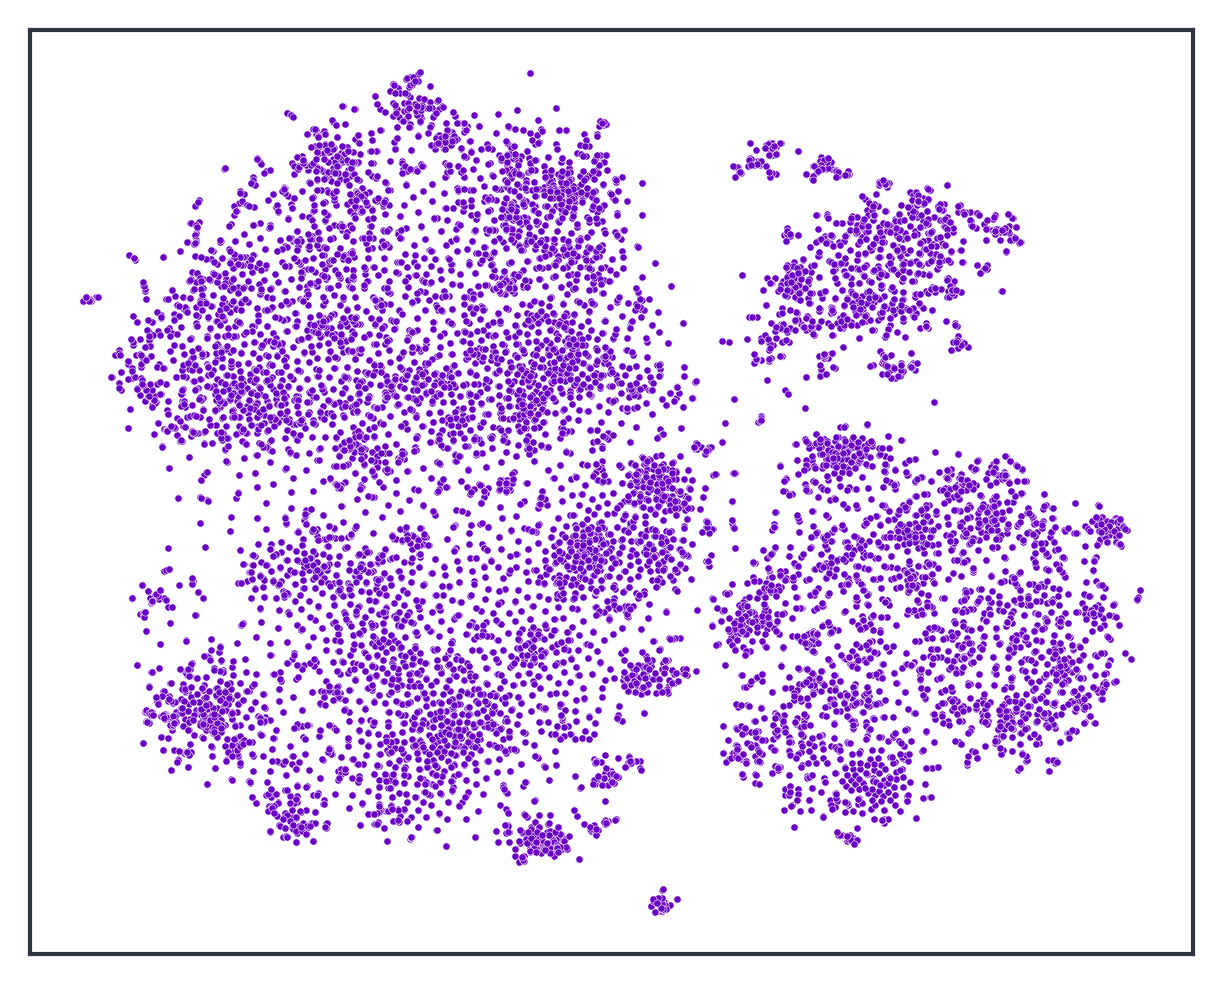

In [11]:
# 向量可视化
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

# 加载 .npy 文件
embeddings = np.load('draw-data/emb/bb-stsb-train.npy')

# 采样1000
# np.random.seed(42)
# idx = np.random.choice(len(embeddings), 1000, replace=False)
# embeddings = embeddings[idx]

# 使用 t-SNE 降维到 2D
tsne = TSNE(n_components=2, random_state=42)
reduced_embeddings = tsne.fit_transform(embeddings)

# 创建一个数据框来保存降维后的结果
df = pd.DataFrame(reduced_embeddings, columns=['x', 'y'])

# 绘制散点图
plt.figure(figsize=(5, 4), dpi=300)
ax = sns.scatterplot(x='x', y='y', data=df, s=3, color='#6a00c7', alpha=1)

# 设置边框颜色和宽度
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_color('#2f3542')
    ax.spines[spine].set_linewidth(1)

# 不显示 x 和 y 轴
# ax.set_title('title', fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

# 显示图形
plt.show()

In [ ]:
# 多语言下向量可视化
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

# 加载 .npy 文件
lang_embeddings = np.load('draw-data/emb/xlm-r-large-multi-stsb-train.npz')
lang_list = ["en","de","es","fr","it","nl","pl","pt","ru","zh"]

# 使用 t-SNE 降维到 2D
tsne = TSNE(n_components=2, random_state=42)
reduced_embeddings = tsne.fit_transform(embeddings)

# 创建一个数据框来保存降维后的结果
df = pd.DataFrame(reduced_embeddings, columns=['x', 'y'])

# 绘制散点图
plt.figure(figsize=(5, 4), dpi=300)
ax = sns.scatterplot(x='x', y='y', data=df, s=3, color='#6a00c7', alpha=1)

# 设置边框颜色和宽度
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_color('#2f3542')
    ax.spines[spine].set_linewidth(1)

# 不显示 x 和 y 轴
# ax.set_title('title', fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

# 显示图形
plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

# 加载嵌入数据
# lang_embeddings = np.load('draw-data/emb/labse-multi-stsb-train.npz')
lang_embeddings = np.load('draw-data/emb/xlm-r-large-multi-stsb-train.npz')

# 定义语言及其全称和颜色
lang_list = [
    ("en", "English", "#0984e3"),
    ("de", "German", "#fa8231"),
    ("fr", "French", "#079992"),
    ("ru", "Russian", "#a6559d"),
    ("zh", "Chinese", "#dc6b82"),
]

# 提取所有语言的嵌入和对应的标签
embeddings = []
labels = []

# 为每个语言添加相应的嵌入数据和标签
for lang, full_name, color in lang_list:
    embeddings.append(lang_embeddings[lang])
    labels.extend([full_name] * len(lang_embeddings[lang]))

# 将所有语言的嵌入数据合并成一个大的矩阵
embeddings = np.concatenate(embeddings, axis=0)

# 使用 t-SNE 降维到 2D
tsne = TSNE(n_components=2, random_state=918)
embeddings_2d = tsne.fit_transform(embeddings)

# 将降维后的数据转换为 DataFrame 以便绘图
df = pd.DataFrame(embeddings_2d, columns=['x', 'y'])
df['language'] = labels

df['id'] = df.groupby('language').cumcount()


# 创建语言到颜色的映射
lang_to_color = {full_name: color for _, full_name, color in lang_list}

# 设置 seaborn 样式
sns.set(style="whitegrid")

# 绘制散点图
plt.figure(figsize=(5, 3), dpi=600)
ax = sns.scatterplot(data=df, x='x', y='y', hue='language', palette=lang_to_color, s=9, alpha=1, edgecolor='#57606f', linewidth=0.2, zorder=2)

# 添加连接线
# 添加连接线，按照语言的相同索引连接点

# 按照 id 分组，获取每个 id 对应的点
for group_id, group_data in df.groupby('id'):
    # 确保组内有超过一个点才能连接
    if len(group_data) > 1:
        # 按照顺序连接点
        for i in range(len(group_data) - 1):
            ax.plot([group_data.iloc[i]['x'], group_data.iloc[i + 1]['x']],
                    [group_data.iloc[i]['y'], group_data.iloc[i + 1]['y']],
                    color='#7d5284', linewidth=0.1, alpha=0.2, zorder=1)  # 设置连接线的透明度和宽度



# 添加标题
# plt.title("t-SNE Visualization of Multilingual Embeddings", fontsize=16)

# 显示图例
plt.legend(title='Language', loc='upper right', frameon=False, markerscale=2, fontsize=6)

# 设置边框颜色和宽度
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_color('#2f3542')
    ax.spines[spine].set_linewidth(1)

# 不显示 x 和 y 轴
# ax.set_title('title', fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

# 显示图形
plt.tight_layout()
plt.show()